# RetailPulse - Day 10

## Inventory Optimization Logic using Forecasted Demand

Objective:
Use the hybrid ensemble demand forecast (Day 8) to calculate reorder points, safety stock, and recommended order quantities, reducing overstock/understock risk.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Step 1: Load Forecast and Historical Sales Data

In [2]:
daily_sales = pd.read_csv("../data/daily_sales.csv")

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

future_forecast = pd.read_csv("../data/ensemble_future_30_days.csv")

future_forecast["ds"] = pd.to_datetime(future_forecast["ds"])

print(daily_sales.shape)
print(future_forecast.shape)

future_forecast.head()

(305, 2)
(30, 4)


,ds,prophet_yhat,lstm_yhat,ensemble_yhat
0,2011-12-10,78109.165063,29094.355,73207.684104
1,2011-12-11,47356.913283,28060.115,45427.233430
2,2011-12-12,59679.835550,27317.268,56443.578801
3,2011-12-13,63011.027519,26771.184,59387.043175
4,2011-12-14,59096.802038,26378.281,55824.949959


## Step 2: Demand Statistics from Historical Data

We use historical daily sales to estimate average demand and demand variability (standard deviation), which are needed for safety stock calculations.

In [3]:
avg_daily_demand = daily_sales["Sales"].mean()

std_daily_demand = daily_sales["Sales"].std()

print("Average Daily Demand:", round(avg_daily_demand, 2))
print("Std Dev of Daily Demand:", round(std_daily_demand, 2))

Average Daily Demand: 29138.45
Std Dev of Daily Demand: 17835.46


## Step 3: Define Inventory Parameters

We define simple, configurable business parameters:
- **Lead time**: days it takes for new stock to arrive after ordering
- **Service level (Z-score)**: how much safety stock to hold against demand variability (95% service level -> Z = 1.65)
- **Current stock**: assumed starting inventory level (can be adjusted)

In [4]:
LEAD_TIME_DAYS = 7

SERVICE_LEVEL_Z = 1.65  # ~95% service level

CURRENT_STOCK = avg_daily_demand * 15  # assume ~15 days of stock on hand

print("Lead Time (days):", LEAD_TIME_DAYS)
print("Service Level Z-score:", SERVICE_LEVEL_Z)
print("Assumed Current Stock:", round(CURRENT_STOCK, 2))

Lead Time (days): 7
Service Level Z-score: 1.65
Assumed Current Stock: 437076.73


## Step 4: Safety Stock and Reorder Point

**Safety Stock** = Z * std_daily_demand * sqrt(lead_time)

**Reorder Point (ROP)** = (avg_daily_demand * lead_time) + safety_stock

When projected stock falls below ROP, a reorder should be triggered.

In [5]:
safety_stock = SERVICE_LEVEL_Z * std_daily_demand * np.sqrt(LEAD_TIME_DAYS)

reorder_point = (avg_daily_demand * LEAD_TIME_DAYS) + safety_stock

print("Safety Stock:", round(safety_stock, 2))
print("Reorder Point (ROP):", round(reorder_point, 2))

Safety Stock: 77860.53
Reorder Point (ROP): 281829.67


## Step 5: Project Future Stock Levels using Ensemble Forecast

Starting from `CURRENT_STOCK`, we subtract each day's forecasted demand to simulate stock depletion over the next 30 days, and flag the day when stock falls below the reorder point.

In [6]:
projection = future_forecast[["ds","ensemble_yhat"]].copy()

projection = projection.rename(columns={"ensemble_yhat":"ForecastedDemand"})

projection["ForecastedDemand"] = projection["ForecastedDemand"].clip(lower=0)

stock_levels = []

stock = CURRENT_STOCK

for demand in projection["ForecastedDemand"]:

    stock = stock - demand

    stock_levels.append(stock)

projection["ProjectedStock"] = stock_levels

projection["BelowReorderPoint"] = projection["ProjectedStock"] < reorder_point

projection.head(10)

,ds,ForecastedDemand,ProjectedStock,BelowReorderPoint
0,2011-12-10,73207.684104,363869.048388,False
1,2011-12-11,45427.233430,318441.814958,False
2,2011-12-12,56443.578801,261998.236157,True
3,2011-12-13,59387.043175,202611.192982,True
4,2011-12-14,55824.949959,146786.243023,True
5,2011-12-15,61206.658761,85579.584261,True
6,2011-12-16,52596.491120,32983.093141,True
7,2011-12-17,66474.295148,-33491.202007,True
8,2011-12-18,37791.897165,-71283.099172,True
9,2011-12-19,48040.405669,-119323.504841,True


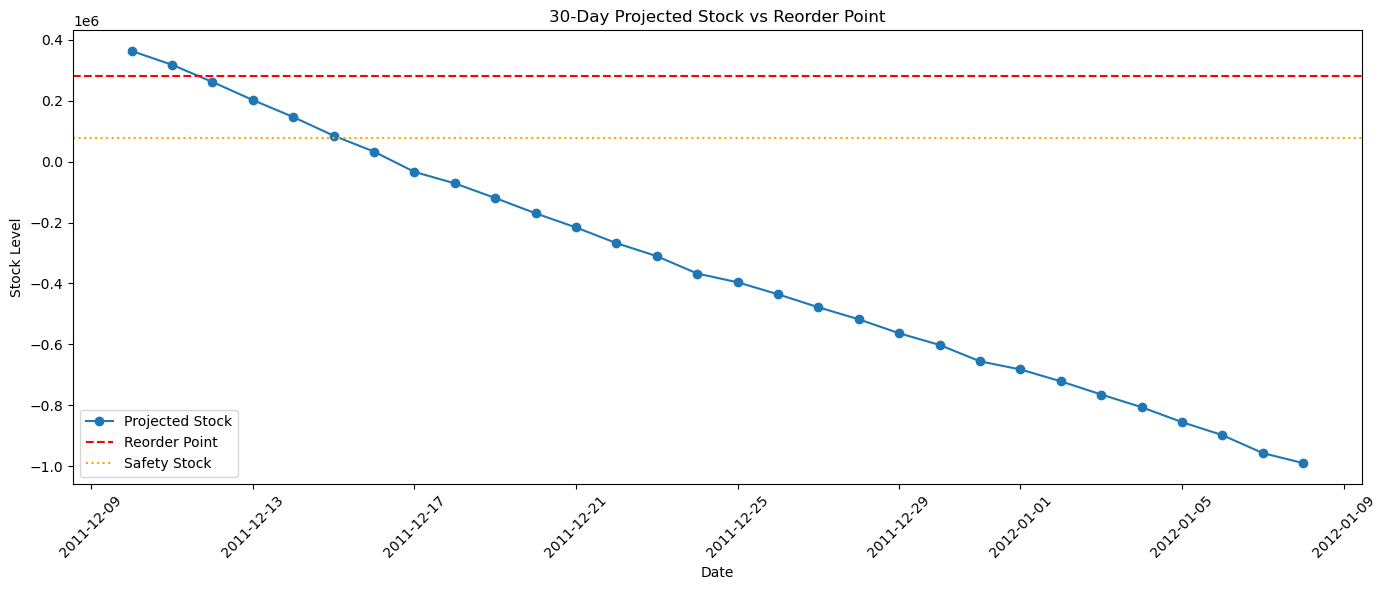

In [7]:
plt.figure(figsize=(14,6))

plt.plot(projection["ds"], projection["ProjectedStock"], label="Projected Stock", marker="o")

plt.axhline(reorder_point, color="red", linestyle="--", label="Reorder Point")

plt.axhline(safety_stock, color="orange", linestyle=":", label="Safety Stock")

plt.title("30-Day Projected Stock vs Reorder Point")

plt.xlabel("Date")
plt.ylabel("Stock Level")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

## Step 6: Identify Reorder Trigger Date

In [8]:
reorder_dates = projection[projection["BelowReorderPoint"]]

if len(reorder_dates) > 0:

    first_reorder_date = reorder_dates.iloc[0]["ds"]

    print("Stock falls below Reorder Point on:", first_reorder_date.date())

    print("Days until reorder needed:", (first_reorder_date - projection['ds'].iloc[0]).days + 1)

else:

    print("Stock does not fall below Reorder Point within the 30-day forecast window.")

Stock falls below Reorder Point on: 2011-12-12
Days until reorder needed: 3


## Step 7: Recommended Order Quantity (Economic-style Calculation)

**Recommended Order Quantity** = Total forecasted demand over the planning horizon + safety stock - current stock (floored at 0).

This tells us how much to order now to cover demand for the next 30 days plus a safety buffer.

In [9]:
total_forecasted_demand_30d = projection["ForecastedDemand"].sum()

recommended_order_qty = max(
    0,
    total_forecasted_demand_30d + safety_stock - CURRENT_STOCK
)

print("Total Forecasted Demand (30 days):", round(total_forecasted_demand_30d, 2))
print("Recommended Order Quantity:", round(recommended_order_qty, 2))

Total Forecasted Demand (30 days): 1427548.16
Recommended Order Quantity: 1068331.96


## Step 8: Overstock / Understock Risk Classification

We classify each day's projected stock level as Understock, Optimal, or Overstock relative to the reorder point and a defined overstock ceiling (e.g., 2x reorder point).

In [10]:
OVERSTOCK_CEILING = reorder_point * 2

def classify_stock(level):

    if level < reorder_point:
        return "Understock Risk"

    elif level > OVERSTOCK_CEILING:
        return "Overstock Risk"

    else:
        return "Optimal"

projection["StockStatus"] = projection["ProjectedStock"].apply(classify_stock)

projection["StockStatus"].value_counts()

StockStatus
Understock Risk    28
Optimal             2
Name: count, dtype: int64

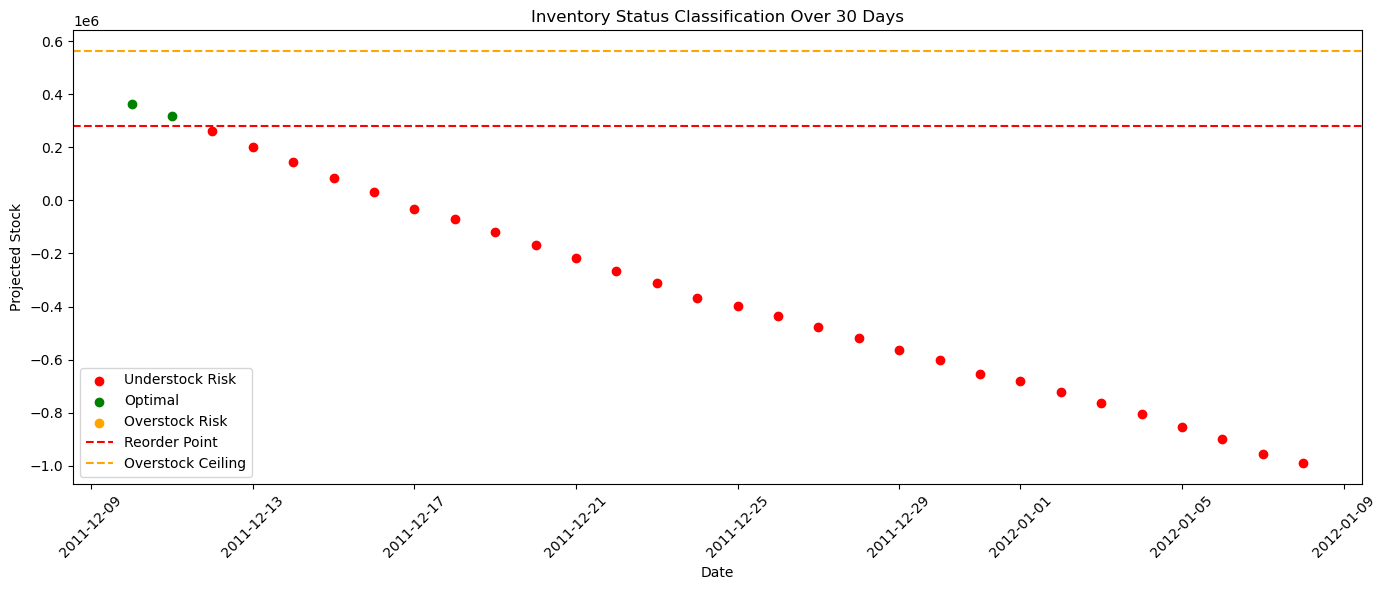

In [11]:
status_colors = {
    "Understock Risk": "red",
    "Optimal": "green",
    "Overstock Risk": "orange"
}

plt.figure(figsize=(14,6))

for status, color in status_colors.items():

    subset = projection[projection["StockStatus"] == status]

    plt.scatter(subset["ds"], subset["ProjectedStock"], color=color, label=status)

plt.axhline(reorder_point, color="red", linestyle="--", label="Reorder Point")
plt.axhline(OVERSTOCK_CEILING, color="orange", linestyle="--", label="Overstock Ceiling")

plt.title("Inventory Status Classification Over 30 Days")

plt.xlabel("Date")
plt.ylabel("Projected Stock")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

## Step 9: Inventory Summary Table

In [12]:
inventory_summary = pd.DataFrame({
    "Metric": [
        "Average Daily Demand",
        "Std Dev Daily Demand",
        "Lead Time (days)",
        "Service Level Z-score",
        "Safety Stock",
        "Reorder Point",
        "Assumed Current Stock",
        "Total Forecasted Demand (30d)",
        "Recommended Order Quantity",
        "Overstock Ceiling"
    ],
    "Value": [
        round(avg_daily_demand, 2),
        round(std_daily_demand, 2),
        LEAD_TIME_DAYS,
        SERVICE_LEVEL_Z,
        round(safety_stock, 2),
        round(reorder_point, 2),
        round(CURRENT_STOCK, 2),
        round(total_forecasted_demand_30d, 2),
        round(recommended_order_qty, 2),
        round(OVERSTOCK_CEILING, 2)
    ]
})

inventory_summary

,Metric,Value
0,Average Daily Demand,29138.45
1,Std Dev Daily Demand,17835.46
2,Lead Time (days),7.00
3,Service Level Z-score,1.65
4,Safety Stock,77860.53
5,Reorder Point,281829.67
6,Assumed Current Stock,437076.73
7,Total Forecasted Demand (30d),1427548.16
8,Recommended Order Quantity,1068331.96
9,Overstock Ceiling,563659.34


## Step 10: Save Results

In [13]:
projection.to_csv("../data/inventory_projection.csv", index=False)

inventory_summary.to_csv("../data/inventory_summary.csv", index=False)

print("Inventory optimization results saved")

Inventory optimization results saved


# Day 10 Findings

1. Calculated average daily demand and demand variability from historical sales.
2. Defined inventory parameters: lead time, service level (Z-score), and assumed current stock.
3. Computed safety stock and reorder point using standard inventory formulas.
4. Projected stock depletion over the next 30 days using the Day 8 ensemble forecast, identifying when a reorder is needed.
5. Calculated a recommended order quantity to cover forecasted demand plus safety buffer.
6. Classified each forecasted day as Understock Risk, Optimal, or Overstock Risk relative to reorder point and overstock ceiling.
7. Saved the 30-day inventory projection and summary metrics for use in the dashboard (Week 3).